In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier


In [2]:
df = pd.read_csv('/Users/shivendragupta/Desktop/Machine Learning/iris.csv')

In [3]:
df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['variety'] = le.fit_transform(df.iloc[:,-1])

In [10]:
df_new = df[df['variety']!=0][['sepal.width','petal.length','variety']]

In [11]:
df_new.head()

,sepal.width,petal.length,variety
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [12]:
import matplotlib.pyplot as plt

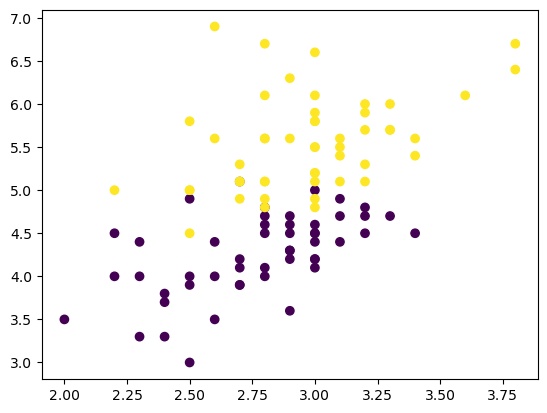

In [14]:
plt.scatter(df_new['sepal.width'],df_new['petal.length'],c=df_new['variety'])

In [17]:
df = df_new.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

df_train

,sepal.width,petal.length,variety
92,2.6,4.0,1
59,2.7,3.9,1
106,2.5,4.5,2
140,3.1,5.6,2
144,3.3,5.7,2
61,3.0,4.2,1
51,3.2,4.5,1
80,2.4,3.8,1
102,3.0,5.9,2
63,2.9,4.7,1


In [18]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [19]:
X_test

array([[2.9, 6.3],
       [3. , 4.5],
       [2.5, 4. ],
       [3. , 5.8],
       [2. , 3.5]])

Case 1 - Bagging

In [29]:
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

In [30]:
df_bag

,sepal.width,petal.length,variety
144,3.3,5.7,2
106,2.5,4.5,2
92,2.6,4.0,1
144,3.3,5.7,2
80,2.4,3.8,1
140,3.1,5.6,2
144,3.3,5.7,2
106,2.5,4.5,2


In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score

In [25]:
dt1 = DecisionTreeClassifier()

In [31]:
dt1.fit(X,y)

DecisionTreeClassifier()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8

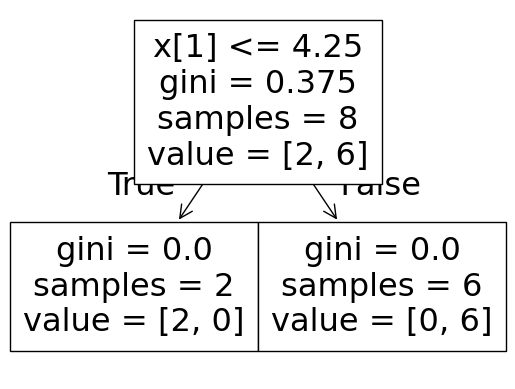

In [38]:
plot_tree(dt1)

accuracy_score(y_test,dt1.predict(X_test))

In [34]:
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

In [35]:
dt2 = DecisionTreeClassifier()

In [36]:
dt2.fit(X,y)

DecisionTreeClassifier()

[Text(0.5, 0.75, 'x[1] <= 5.2\ngini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.625, 0.5, '  False')]

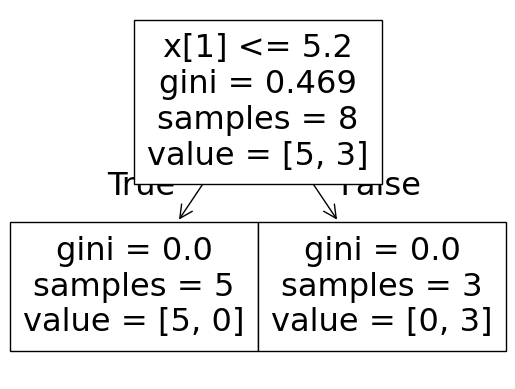

In [37]:
plot_tree(dt2)

In [39]:
accuracy_score(y_test,dt2.predict(X_test))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0

In [40]:
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

In [41]:
dt3 = DecisionTreeClassifier()

dt3.fit(X,y)

DecisionTreeClassifier()

[Text(0.4, 0.875, 'x[1] <= 4.35\ngini = 0.5\nsamples = 8\nvalue = [4, 4]'),
 Text(0.2, 0.625, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'x[1] <= 5.05\ngini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'x[0] <= 2.85\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.2, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.375, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]')]

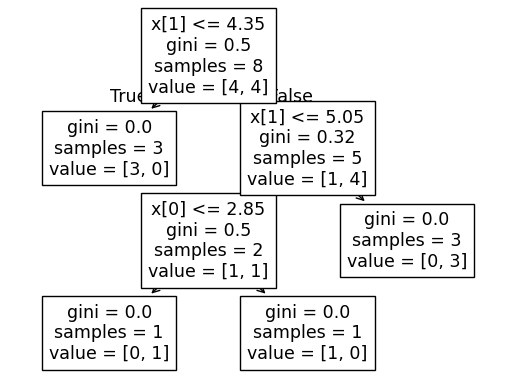

In [42]:
plot_tree(dt3)

In [43]:
accuracy_score(y_test,dt3.predict(X_test))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0

In [44]:
df_test

,sepal.width,petal.length,variety
115,3.2,5.3,2
122,2.8,6.7,2
87,2.3,4.4,1
97,2.9,4.3,1
52,3.1,4.9,1


In [47]:
import numpy as np
print(dt1.predict(np.array([2.9,4.3	]).reshape(1,2)))
print(dt2.predict(np.array([2.9,4.3	]).reshape(1,2)))
print(dt3.predict(np.array([2.9,4.3	]).reshape(1,2)))

[2]
[1]
[1]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Types of bagging 

Pasting 

* Row Sampling without replacement

In [48]:
df_train.sample(8)

,sepal.width,petal.length,variety
106,2.5,4.5,2
144,3.3,5.7,2
51,3.2,4.5,1
92,2.6,4.0,1
80,2.4,3.8,1
61,3.0,4.2,1
59,2.7,3.9,1
63,2.9,4.7,1


Random Subspaces

* Column sampling (With or without)

In [52]:
df_train.sample(8)

,sepal.width,petal.length,variety
102,3.0,5.9,2
61,3.0,4.2,1
59,2.7,3.9,1
51,3.2,4.5,1
63,2.9,4.7,1
144,3.3,5.7,2
106,2.5,4.5,2
80,2.4,3.8,1


In [54]:
df.sample(2,replace=True,axis=1)

,variety,petal.length
139,2,5.4
91,1,4.6
51,1,4.5
112,2,5.5
88,1,4.1
...,...,...
65,1,4.4
86,1,4.7
103,2,5.6
62,1,4.0


Random Patches

* Both row and column sampling

In [55]:
df.sample(8,replace=True).sample(2,replace=True,axis=1)

,variety,petal.length
103,2,5.6
59,1,3.9
66,1,4.5
71,1,4.0
89,1,4.0
103,2,5.6
135,2,6.1
83,1,5.1
